# 07 · Question 3: the most liveable and affordable suburbs

**Project question 3:** *What are the most liveable and affordable suburbs according to your chosen metrics?*

**Answer in short:** see the summary at the end (filled in after running).

**How liveability is measured.** We follow the **Urban Liveability Index (ULI)** (Higgs et al., 2019), a published
measure built for Melbourne and used by the Australian Urban Observatory, rather than inventing our own formula:

1. **Domains.** Badland et al. (2014) reviewed Australian policy and research and identified the domains that make a
   place liveable. We measure the seven we have data for: transport, education, public open space, local food and
   shops, health services, leisure and culture, and access to jobs.
2. **Access score per home.** For transport, schools, parks and shops we use the ULI's *soft threshold*,
   `1 / (1 + exp(5 × (d − c) / c))`, where `d` is the distance and `c` the policy walking distance: about 1 well
   within `c`, 0.5 at `c`, falling towards 0 beyond it (Higgs et al., 2019, p. 5). The distances are the ULI's
   Victorian planning standards: train 800 m, tram 600 m, bus 400 m, school 1,600 m, park 400 m (Higgs et al., 2019,
   p. 3–5), and shops 800 m, the 20-minute neighbourhood walk (Department of Transport and Planning, 2026). Health,
   leisure and jobs use log distance or log counts.
3. **Same scale.** Each domain is rescaled to mean 100, SD 10, limited to 70–130 (Higgs et al., 2019, p. 7).
4. **Equal weights with a balance penalty.** As in the ULI, the domains are not given different weights; the score is
   their average minus a small penalty for uneven performance (the Mazziotta–Pareto method; Higgs et al., 2019, p. 7–8).
   Why equal weights, and their limits, are explained in section 2.
5. **Suburb score** = the average over every listed home in the suburb (suburbs with at least 10 listings).

**Affordability is kept separate**, so we can find suburbs that are *both* liveable and affordable: median annual
rent divided by the SA2's median personal income (notebook 04). Putting rent inside the liveability score would be
circular, because notebook 06 shows liveable locations already command higher rents.

**Inputs:** `listings_final.parquet` (05), `rent_forecast_areas.csv` and `dffh_area_suburb_crosswalk.csv` (03).
**Outputs:** `data/curated/suburb_liveability.csv` (suburb summaries only, safe to share) and plots in `plots/`.

In [61]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # shared project code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config, style
style.apply()
MIN_LISTINGS = 10   # suburbs need at least this many listed homes to be ranked

## 1. Data
Usable listings from both snapshots with valid coordinates (so they have location features from 05). Using every
listed home describes the kind of housing actually on offer in each suburb.

In [62]:
df = pd.read_parquet(config.LISTINGS_FINAL)
use = df[df["usable"] & df["train_km"].notna()].copy()
use.groupby("snapshot").agg(listings=("listing_id", "size"), suburbs=("suburb_key", "nunique"))

,listings,suburbs
snapshot,,
2025-09,12292,644
2026-09,9157,609


## 2. Liveability domains for every home
`access()` is the ULI soft threshold; `scale()` puts each domain on the ULI scale. For transport, a home counts as
well served if **any** of train, tram or bus is within its walking distance, so the best of the three is used
(the ULI's public transport standard is "a bus stop within 400 m, tram stop within 600 m or train station within
800 m"; Higgs et al., 2019, p. 4).

In [63]:
def access(d_km, threshold_km, k=5):
    "ULI soft threshold (Higgs et al. 2019): ~1 well within the threshold, 0.5 at it, falling to 0 beyond."
    return 1 / (1 + np.exp(np.minimum(k * (d_km - threshold_km) / threshold_km, 50)))   # cap avoids overflow far away

def scale(s):
    "ULI scaling: mean 100, SD 10, limited to 70-130."
    return (100 + 10 * (s - s.mean()) / s.std()).clip(70, 130)

DOMAINS = {   # domain: (score before scaling, how it is measured)
    "transport": (np.maximum.reduce([access(use["train_km"], 0.8), access(use["tram_stop_km"], 0.6),
                                     access(use["bus_stop_km"], 0.4)]), "train 800 m / tram 600 m / bus 400 m"),
    "education": (access(use["school_km"], 1.6), "school within 1,600 m"),
    "open_space": (access(use["park_km"], 0.4), "park within 400 m"),
    "food_shops": (access(use["shop_km"], 0.8), "supermarket or shopping centre within 800 m"),
    "health": (-np.log1p(use["hospital_km"]), "closer to a hospital"),
    "leisure": (np.log1p(use["entertainment_within_1km"]), "more cafes, restaurants, pubs, cinemas within 1 km"),
    "jobs_access": (-np.log1p(use["cbd_route_km"]), "shorter drive to the CBD"),
}
domains = pd.DataFrame({d: scale(pd.Series(v, index=use.index)) for d, (v, _) in DOMAINS.items()})

mean, sd = domains.mean(axis=1), domains.std(axis=1, ddof=0)
use["liveability"] = mean - sd * (sd / mean)        # ULI: equal-weight average minus a penalty for uneven domains
use["liveability_plain"] = mean                     # plain average, used as a sensitivity check

pd.DataFrame({"measured as": {d: m for d, (_, m) in DOMAINS.items()},
              "median (scaled)": domains.median().round(1)})

,measured as,median (scaled)
transport,train 800 m / tram 600 m / bus 400 m,104.9
education,"school within 1,600 m",103.4
open_space,park within 400 m,104.5
food_shops,supermarket or shopping centre within 800 m,103.7
health,closer to a hospital,101.8
leisure,"more cafes, restaurants, pubs, cinemas within ...",98.9
jobs_access,shorter drive to the CBD,99.3


### Why equal weights?
- **Follows the published index.** The ULI "does not directly weight the indicators from which it is formed"
  (Higgs et al., 2019, p. 21). Its authors considered data-driven weights (factor analysis, PCA) but noted that
  "such weighting will be contingent on the sample used to inform the analysis and so this weighting may not be
  generalisable to other contexts", and chose a method whose meaning is "readily conveyable in plain language to a
  lay audience" (p. 21). Our client is a lay audience too.
- **The standard approach.** "Most composite indicators rely on equal weighting" (OECD/JRC, 2008, p. 31); it is "the
  most common scheme appearing in the development of composite indicators" (Greco et al., 2019, p. 66).
- **Suits our situation.** Equal weights are used when there is "a lack of theoretical structure to justify a
  differential weighting scheme", "no agreement between decision makers" or "inadequate statistical and/or empirical
  knowledge" (Greco et al., 2019, p. 66). There is no agreed basis for saying a train station matters twice as much
  as a park.
- **Tested, not assumed.** Because weights "are essentially value judgements" (OECD/JRC, 2008, p. 31), the handbook
  recommends sensitivity analysis to check that results are robust (OECD/JRC, 2008, section 1.7). Section 3 shows
  the suburb ranking barely changes under other weightings.

## 3. Suburb liveability and affordability
Suburb liveability is the average over its listed homes. Affordability is the median weekly rent of the **latest**
snapshot × 52, divided by the SA2's median personal income (lower = more affordable). The "30% of income" housing
stress rule used in the ULI (Higgs et al., 2019, p. 5) is based on *household* income, so with personal income the
ratio is higher; we use it to **rank** suburbs, not to label them as in stress.

In [64]:
latest = use["snapshot"] == use["snapshot"].max()
suburbs = use.groupby("suburb_key").agg(
    suburb=("suburb", "first"), listings=("listing_id", "size"),
    liveability=("liveability", "mean"), liveability_plain=("liveability_plain", "mean"),
    metro=("is_metro", lambda s: s.mode().iat[0] if s.notna().any() else np.nan),
    median_income=("MEDIAN_INCOME_2022_23", "median"))
suburbs[list(DOMAINS)] = domains.groupby(use["suburb_key"]).mean()
suburbs["median_rent"] = use[latest].groupby("suburb_key")["weekly_rent"].median()
suburbs = suburbs[suburbs["listings"] >= MIN_LISTINGS].dropna(subset=["median_rent", "median_income"])
suburbs["rent_to_income"] = suburbs["median_rent"] * 52 / suburbs["median_income"]
suburbs["suburb"] = suburbs["suburb"].str.title()
suburbs["liveability_rank"] = suburbs["liveability"].rank(ascending=False, method="min").astype(int)
suburbs["affordability_rank"] = suburbs["rent_to_income"].rank(method="min").astype(int)
print(f"{len(suburbs)} suburbs with at least {MIN_LISTINGS} listings "
      f"({int((suburbs['metro'] == True).sum())} in Greater Melbourne)")

cols = ["suburb", "listings", "liveability", "median_rent", "rent_to_income"]
print("Most liveable suburbs")
suburbs.sort_values("liveability", ascending=False)[cols].head(15).round(2).reset_index(drop=True)

370 suburbs with at least 10 listings (287 in Greater Melbourne)
Most liveable suburbs


,suburb,listings,liveability,median_rent,rent_to_income
0,Melbourne,585,110.73,680.0,0.94
1,Carlton,224,110.43,455.0,0.73
2,West Melbourne,134,109.59,625.0,0.59
3,Fitzroy,38,109.13,600.0,0.44
4,Collingwood,49,108.95,550.0,0.36
5,East Melbourne,42,108.64,710.0,0.46
6,Southbank,572,108.42,750.0,0.64
7,North Melbourne,152,108.35,575.0,0.55
8,Brunswick,129,108.02,682.5,0.50
9,Travancore,20,107.72,530.0,0.45


### Robustness: does the ranking depend on the weighting?
Following OECD/JRC (2008, section 1.7), we compare the suburb ranking with (a) a plain average without the ULI
penalty and (b) the score recalculated with each domain left out. Values close to 1 mean the ranking does not hinge
on that choice.

In [65]:
robust = {"plain average instead of the ULI penalty":
          suburbs["liveability"].corr(suburbs["liveability_plain"], method="spearman")}
for d in DOMAINS:
    without = domains.drop(columns=d).mean(axis=1).groupby(use["suburb_key"]).mean().reindex(suburbs.index)
    robust[f"drop {d}"] = suburbs["liveability"].corr(without, method="spearman")
pd.Series(robust, name="rank agreement with the main score (Spearman)").round(3).to_frame()

,rank agreement with the main score (Spearman)
plain average instead of the ULI penalty,0.999
drop transport,0.994
drop education,0.995
drop open_space,0.984
drop food_shops,0.988
drop health,0.978
drop leisure,0.993
drop jobs_access,0.978


## 4. Liveable *and* affordable
Suburbs in the top half for liveability **and** the top half for affordability, ranked by liveability. Metropolitan
and regional suburbs are listed separately because the transport and jobs domains favour Melbourne.

In [66]:
both = suburbs[(suburbs["liveability"] >= suburbs["liveability"].median())
               & (suburbs["rent_to_income"] <= suburbs["rent_to_income"].median())]
show = ["suburb", "liveability", "liveability_rank", "median_rent", "rent_to_income", "affordability_rank"]
for name, part in [("Greater Melbourne", both[both["metro"] == True]), ("Regional Victoria", both[both["metro"] == False])]:
    print(f"{name}: {len(part)} suburbs are both more liveable and more affordable than the median")
    display(part.sort_values("liveability", ascending=False)[show].head(10).round(2).reset_index(drop=True))

Greater Melbourne: 77 suburbs are both more liveable and more affordable than the median


,suburb,liveability,liveability_rank,median_rent,rent_to_income,affordability_rank
0,Fitzroy,109.13,4,600.0,0.44,66
1,Collingwood,108.95,5,550.0,0.36,11
2,East Melbourne,108.64,6,710.0,0.46,97
3,Brunswick,108.02,9,682.5,0.50,163
4,Travancore,107.72,10,530.0,0.45,85
5,Abbotsford,107.70,11,657.5,0.45,92
6,Richmond,107.41,13,700.0,0.49,148
7,Kensington,107.23,14,750.0,0.50,165
8,South Yarra,107.10,16,665.0,0.47,122
9,Prahran,107.10,17,625.0,0.42,54


Regional Victoria: 6 suburbs are both more liveable and more affordable than the median


,suburb,liveability,liveability_rank,median_rent,rent_to_income,affordability_rank
0,Geelong,102.76,71,525.0,0.46,102
1,Geelong West,101.75,105,450.0,0.36,10
2,Newtown,100.40,140,515.0,0.40,29
3,Bell Park,100.33,142,500.0,0.46,105
4,Newcomb,99.71,166,490.0,0.50,170
5,Redan,99.27,181,450.0,0.46,108


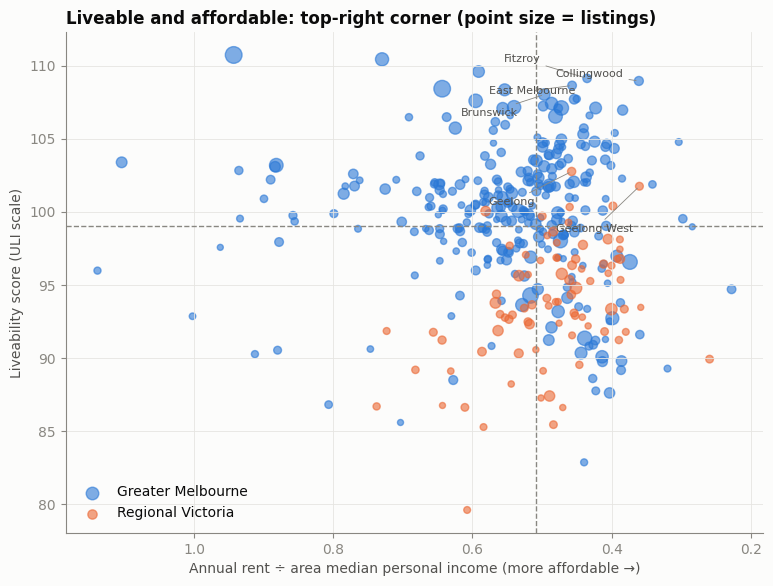

In [67]:
fig, ax = plt.subplots(figsize=(9, 6.5))
for flag, colour, label in [(True, style.BLUE, "Greater Melbourne"), (False, style.ORANGE, "Regional Victoria")]:
    p = suburbs[suburbs["metro"] == flag]
    ax.scatter(p["rent_to_income"], p["liveability"], s=np.sqrt(p["listings"]) * 6, alpha=0.6, color=colour, label=label)
ax.axvline(suburbs["rent_to_income"].median(), color=style.MUTED, linewidth=1, linestyle="--")
ax.axhline(suburbs["liveability"].median(), color=style.MUTED, linewidth=1, linestyle="--")
labels = pd.concat([both[both["metro"] == True].nlargest(4, "liveability"),
                    both[both["metro"] == False].nlargest(2, "liveability")])
for i, (_, r) in enumerate(labels.iterrows()):
    ax.annotate(r["suburb"], (r["rent_to_income"], r["liveability"]), fontsize=8, color=style.INK_2,
                xytext=(-60, 12 - 9 * i), textcoords="offset points",
                arrowprops=dict(arrowstyle="-", color=style.MUTED, linewidth=0.6))
ax.invert_xaxis()   # more affordable to the right
ax.set(xlabel="Annual rent ÷ area median personal income (more affordable →)", ylabel="Liveability score (ULI scale)",
       title="Liveable and affordable: top-right corner (point size = listings)")
ax.legend(loc="lower left")
fig.savefig(config.PLOTS / "liveability_vs_affordability.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Linking to question 2: liveability vs forecast rent growth
Our investment thesis: buy where forecast rent growth is high **and** the suburb is liveable. Expensive, already-
liveable suburbs may have little growth left, while fast-growing but poorly serviced areas carry risk: Melbourne's
growth-area councils have "large gaps in community infrastructure such as schools and libraries" and more car
dependence (An, 2024, p. 1), and the ULI authors note that fringe areas "may not facilitate affordable living because
they lack proximal access to public transport and local amenities" (Higgs et al., 2019, p. 20).

The shortlist is suburbs with above-median liveability **and** above-median forecast growth. Affordability is not a
filter, since the client's goal is rental return, but it is shown for each suburb: a more affordable suburb may make it
easier to find tenants (a reasonable expectation, not something we test). Each suburb takes the 2025–2030 forecast
growth of its DFFH area (notebook 03); suburbs outside DFFH's areas cannot be placed.

In [68]:
forecast = pd.read_csv(config.CURATED / "rent_forecast_areas.csv")
xwalk = pd.read_csv(config.DFFH_CROSSWALK).dropna(subset=["suburb_key"])
growth = xwalk.merge(forecast[["area", "growth_pa_pct", "growth_pa_low", "growth_pa_high"]],
                     left_on="dffh_area", right_on="area").drop_duplicates("suburb_key").set_index("suburb_key")
invest = suburbs.join(growth[["dffh_area", "growth_pa_pct"]], how="inner")
print(f"{len(invest)} of {len(suburbs)} ranked suburbs have a DFFH growth forecast")

fast = invest[invest["growth_pa_pct"] >= invest["growth_pa_pct"].quantile(0.9)]
print(f"Of the fastest-growing 10% ({len(fast)} suburbs), "
      f"{(fast['liveability'] < suburbs['liveability'].median()).mean():.0%} are below-median liveability")

buy = invest[(invest["liveability"] >= suburbs["liveability"].median())
             & (invest["growth_pa_pct"] >= invest["growth_pa_pct"].median())]
print(f"Shortlist: {len(buy)} suburbs that are liveable and above-median forecast growth")
buy.sort_values("growth_pa_pct", ascending=False)[["suburb", "dffh_area", "liveability", "growth_pa_pct",
                                                     "median_rent", "rent_to_income"]].round(2).reset_index(drop=True)

190 of 370 ranked suburbs have a DFFH growth forecast
Of the fastest-growing 10% (19 suburbs), 68% are below-median liveability
Shortlist: 50 suburbs that are liveable and above-median forecast growth


,suburb,dffh_area,liveability,growth_pa_pct,median_rent,rent_to_income
0,Frankston,Frankston,99.71,6.57,617.5,0.56
1,Croydon,Croydon-Lilydale,100.10,6.48,600.0,0.53
2,Lilydale,Croydon-Lilydale,99.59,6.48,580.0,0.50
3,Bendigo,Bendigo,100.05,6.33,595.0,0.58
4,Port Melbourne,Port Melbourne,103.12,6.04,807.5,0.50
5,Carlton North,Carlton North,106.47,5.84,925.0,0.69
6,Geelong West,Herne Hill-Geelong West,101.75,4.84,450.0,0.36
7,Alphington,Fairfield-Alphington,103.64,4.55,725.0,0.46
8,Fairfield,Fairfield-Alphington,104.77,4.55,435.0,0.30
9,Newcomb,Geelong-Newcombe,99.71,4.44,490.0,0.50


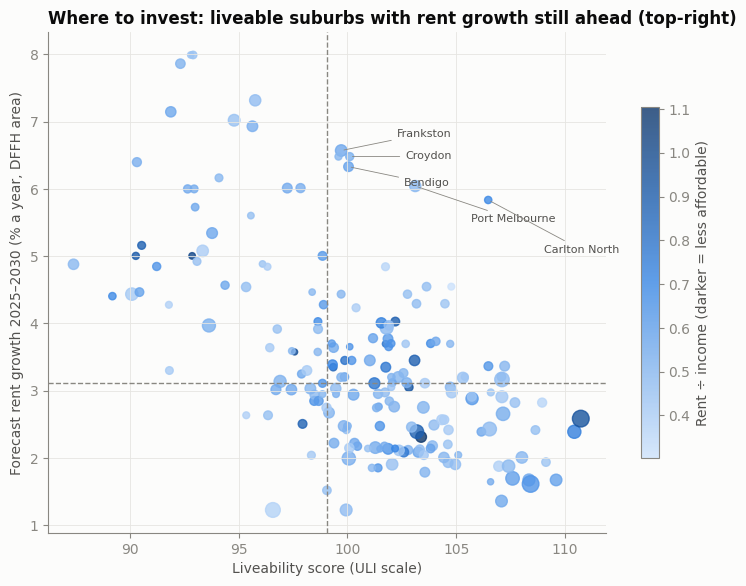

In [69]:
fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(invest["liveability"], invest["growth_pa_pct"], c=invest["rent_to_income"], cmap=style.SEQ,
                s=np.sqrt(invest["listings"]) * 6, alpha=0.8)
ax.axvline(suburbs["liveability"].median(), color=style.MUTED, linewidth=1, linestyle="--")
ax.axhline(invest["growth_pa_pct"].median(), color=style.MUTED, linewidth=1, linestyle="--")
top = buy.sort_values("growth_pa_pct", ascending=False).drop_duplicates("dffh_area").head(5)   # one label per DFFH area
for i, (_, r) in enumerate(top.iterrows()):
    ax.annotate(r["suburb"], (r["liveability"], r["growth_pa_pct"]), fontsize=8, color=style.INK_2,
                xytext=(40, 10 - 12 * i), textcoords="offset points",
                arrowprops=dict(arrowstyle="-", color=style.MUTED, linewidth=0.6))
fig.colorbar(sc, ax=ax, shrink=0.7, label="Rent ÷ income (darker = less affordable)")
ax.set(xlabel="Liveability score (ULI scale)", ylabel="Forecast rent growth 2025–2030 (% a year, DFFH area)",
       title="Where to invest: liveable suburbs with rent growth still ahead (top-right)")
fig.savefig(config.PLOTS / "liveability_vs_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Checks and save

In [70]:
def check(name, ok, detail=""):
    print(f"{'PASS' if ok else 'FAIL'} | {name}" + (f" ({detail})" if detail else ""))

check("every usable listing with coordinates has a liveability score", use["liveability"].notna().all())
check("domain scores are on the ULI scale", domains.mean().sub(100).abs().max() < 2 and domains.min().min() >= 70
      and domains.max().max() <= 130)
check("one row per suburb", suburbs.index.is_unique, f"{len(suburbs)} suburbs")
check("rent-to-income ratios are plausible", suburbs["rent_to_income"].between(0.05, 3).all(),
      f"{suburbs['rent_to_income'].min():.2f}-{suburbs['rent_to_income'].max():.2f}")
r = suburbs["liveability"].corr(suburbs["median_rent"], method="spearman")
check("more liveable suburbs tend to cost more (consistent with notebook 06)", r > 0, f"Spearman {r:.2f}")

out = suburbs.join(growth[["dffh_area", "growth_pa_pct"]], how="left").reset_index()
out.round(4).to_csv(config.CURATED / "suburb_liveability.csv", index=False)
print(f"Saved {len(out)} suburbs to data/curated/suburb_liveability.csv (suburb summaries only)")

PASS | every usable listing with coordinates has a liveability score
PASS | domain scores are on the ULI scale
PASS | one row per suburb (370 suburbs)
PASS | rent-to-income ratios are plausible (0.23-1.14)
PASS | more liveable suburbs tend to cost more (consistent with notebook 06) (Spearman 0.45)
Saved 370 suburbs to data/curated/suburb_liveability.csv (suburb summaries only)


## Summary
**Data:** 21,449 usable listings (12,292 Domain 2025, 9,157 rent.com.au 2026); 370 suburbs with at least 10 listings
(287 in Greater Melbourne, 83 regional).

**Most liveable suburbs.** Inner Melbourne leads: Melbourne CBD (110.7), Carlton (110.4), West Melbourne (109.6),
Fitzroy (109.1) and Collingwood (109.0), followed by East Melbourne, Southbank, North Melbourne, Brunswick and
Travancore. These areas combine public transport, shops, schools, parks and entertainment within walking distance,
consistent with the ULI's finding that liveability is highest in inner Melbourne (Higgs et al., 2019, p. 20).

**The score is robust.** The suburb ranking is almost unchanged with a plain average instead of the ULI penalty
(Spearman 0.999) or with any single domain removed (0.978–0.995), so the result does not depend on the weighting.
More liveable suburbs also have higher rents (Spearman 0.45), consistent with notebook 06.

**Liveable *and* affordable.** 77 Melbourne suburbs and 6 regional suburbs are in the top half for both.
- *Melbourne:* Collingwood stands out (5th most liveable, 11th most affordable), followed by Prahran, Fitzroy,
  Travancore and Abbotsford.
- *Regional:* all six are in Geelong and Ballarat; Geelong West is the best (10th most affordable overall), followed
  by Newtown and Geelong.

**Where to invest (linking to question 2).** 190 of the 370 suburbs have a DFFH rent forecast.
- **Fast growth is usually not liveable:** of the fastest-growing 10% of suburbs (19), **68% have below-median
  liveability**. Our thesis screens these out, as their growth is not backed by amenities (An, 2024).
- **50 suburbs are both liveable and above the median forecast growth.** The strongest on both counts are
  **Carlton North** (liveability 106.5, growth 5.8% a year) and **Port Melbourne** (103.1, 6.0% a year), though both
  have high rents ($925 and $808 a week).
- The highest-growth suburbs on the shortlist, **Frankston** (6.6%), **Croydon** and **Lilydale** (6.5%) and
  **Bendigo** (6.3%), only just pass the liveability cut-off (about 100 vs a median of about 99), so they are
  higher-growth but borderline on liveability.
- If affordability is also wanted (a more affordable suburb may make it easier to find tenants, though we do not
  test this), the best options are **Geelong West** (101.8, 4.8% a year, $450/week) and **Fairfield** (104.8, 4.6% a
  year, $435/week, the most affordable on the shortlist).

## Assumptions and limitations
**Weighting**
- **Equal weights are a judgement, not "no weights".** Equal weighting "does not mean 'no weights', but implicitly
  implies that the weights are equal" (OECD/JRC, 2008, p. 31), and critics argue it is as much a "subjective
  judgement" as any other scheme (Greco et al., 2019, p. 66).
- **Double counting of centrality.** Combining correlated indicators with equal weights can introduce "an element of
  double counting" (OECD/JRC, 2008, p. 32). Inner suburbs score high on transport, leisure and jobs access at once,
  so "being central" carries more than 1/7 of the weight. Dropping any one of these domains barely changes the
  ranking (section 3), which limits but does not remove this effect.
- **Essential vs minor amenities.** Equal weights "miss the point of differentiating between essential and less
  important indicators" (Greco et al., 2019, p. 66): hospital access counts the same as nearby cafes.
- **Liveable for whom?** Different households value amenities differently (e.g. families and schools). The ULI
  authors suggest group-specific weighting profiles as future work (Higgs et al., 2019, p. 21).

**Measurement**
- **Domains we cannot measure:** crime and safety, social cohesion, natural environment (e.g. air quality) and local
  employment (approximated by the drive to the CBD), all domains in Badland et al. (2014).
- **Straight-line distances:** the ULI uses walking-network distances; ours are straight-line per home, so true
  walks can be longer.
- **Stops, not services:** public transport is measured by distance to a stop, not how often services run (the ULI
  authors note the same issue; Higgs et al., 2019, p. 20).
- **Parks:** any park or reserve counts; the ULI counts only public open space larger than 1.5 ha (p. 5).
- **Listings, not all homes:** a suburb's score averages the homes listed for rent, which may differ from all
  housing in the suburb.

**Affordability and growth**
- **Personal income, asking rents:** affordability uses personal income (2022–23), not household income, and asking
  rents, not agreed rents. Student-heavy areas (e.g. Melbourne CBD, Carlton) have low personal incomes, which makes
  them look less affordable; high-income areas (e.g. Toorak, Port Melbourne) can look affordable despite high rents.
- **Melbourne bias:** transport and jobs access favour Melbourne, so regional suburbs are listed separately.
- **Growth link:** forecasts are for DFFH areas (groups of suburbs), so suburbs in the same area share one forecast,
  and about half of the ranked suburbs have no DFFH series.
- **Median cut-offs:** "liveable" and "above-median growth" use simple median splits, so suburbs just either side of
  the line (e.g. Frankston, Lilydale) are borderline cases.

## References
- An, A. (2024). Growing liveable cities: an indicators study of Melbourne's fast-growing metropolitan area.
  *GeoJournal*, 89, 224. https://doi.org/10.1007/s10708-024-11170-y
- Badland, H., Whitzman, C., Lowe, M., Davern, M., Aye, L., Butterworth, I., Hes, D., & Giles-Corti, B. (2014).
  Urban liveability: emerging lessons from Australia for exploring the potential for indicators to measure the
  social determinants of health. *Social Science & Medicine*, 111, 64–73. https://doi.org/10.1016/j.socscimed.2014.04.003
- Department of Transport and Planning (2026). *20-minute neighbourhoods*. Victorian Government.
  https://www.planning.vic.gov.au/guides-and-resources/strategies-and-initiatives/20-minute-neighbourhoods
- Greco, S., Ishizaka, A., Tasiou, M., & Torrisi, G. (2019). On the methodological framework of composite indices: a
  review of the issues of weighting, aggregation, and robustness. *Social Indicators Research*, 141, 61–94.
  https://doi.org/10.1007/s11205-017-1832-9
- Higgs, C., Badland, H., Simons, K., Knibbs, L. D., & Giles-Corti, B. (2019). The Urban Liveability Index: developing
  a policy-relevant urban liveability composite measure and evaluating associations with transport mode choice.
  *International Journal of Health Geographics*, 18, 14. https://doi.org/10.1186/s12942-019-0178-8
- OECD & JRC (2008). *Handbook on Constructing Composite Indicators: Methodology and User Guide*. OECD Publishing.
  https://doi.org/10.1787/9789264043466-en

In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Project root
ROOT = Path.cwd().parent

SA2_ZIP = ROOT / "data" / "raw" / "external" / "SA2_2021_AUST_SHP_GDA2020.zip"

sa2 = gpd.read_file(SA2_ZIP)

print(sa2.shape)
print(sa2.columns.tolist())

In [ ]:
# Keep only Victorian SA2 regions
vic = sa2[sa2["STE_NAME21"] == "Victoria"].copy()

print("Number of Victorian SA2s:", len(vic))
print(vic[["SA2_CODE21", "SA2_NAME21"]].head())

In [ ]:
# Search the ABS SA2 names for our top forecast areas
search_terms = [
    "Frankston",
    "Croydon",
    "Lilydale",
    "Yarra Ranges",
    "Swan Hill",
    "Moe",
    "Newborough",
    "Warragul"
]

for term in search_terms:
    matches = vic[
        vic["SA2_NAME21"].str.contains(term, case=False, na=False)
    ]["SA2_NAME21"].tolist()

    print(f"{term}: {matches}")

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path


# ============================================================
# 1. FORECAST RESULTS
# ============================================================

forecast_regions = {

    "Frankston": {
        "sa2": [
            "Frankston",
            "Frankston North",
            "Frankston South"
        ],
        "growth": 6.6,
        "type": "Metro"
    },

    "Croydon–Lilydale": {
        "sa2": [
            "Croydon Hills - Warranwood",
            "Croydon - East",
            "Croydon - West",
            "Croydon South",
            "Lilydale - Coldstream"
        ],
        "growth": 6.5,
        "type": "Metro"
    },

    # Approximate ABS SA2 representation of the broader
    # Yarra Ranges forecast area.
    "Yarra Ranges": {
        "sa2": [
            "Healesville - Yarra Glen",
            "Mount Dandenong - Olinda",
            "Yarra Valley"
        ],
        "growth": 6.2,
        "type": "Metro"
    },

    "Swan Hill": {
        "sa2": [
            "Swan Hill",
            "Swan Hill Surrounds"
        ],
        "growth": 8.2,
        "type": "Regional"
    },

    "Moe–Newborough": {
        "sa2": [
            "Moe - Newborough"
        ],
        "growth": 8.0,
        "type": "Regional"
    },

    "Warragul": {
        "sa2": [
            "Warragul"
        ],
        "growth": 7.9,
        "type": "Regional"
    }
}


# ============================================================
# 2. CHECK WHICH SA2 NAMES ACTUALLY EXIST
# ============================================================

available_sa2 = set(vic["SA2_NAME21"])

print("SA2 matching check:\n")

for region, info in forecast_regions.items():

    valid = [
        name for name in info["sa2"]
        if name in available_sa2
    ]

    missing = [
        name for name in info["sa2"]
        if name not in available_sa2
    ]

    print(f"{region}")
    print("  Found:", valid)

    if missing:
        print("  Missing:", missing)

    # Only retain valid names
    info["sa2"] = valid

    print()


# ============================================================
# 3. BUILD ONE GEOMETRY FOR EACH FORECAST REGION
# ============================================================

region_rows = []

for region, info in forecast_regions.items():

    matched = vic[
        vic["SA2_NAME21"].isin(info["sa2"])
    ]

    if matched.empty:
        print(f"WARNING: No geometry found for {region}")
        continue

    combined_geometry = matched.geometry.union_all()

    region_rows.append({
        "region": region,
        "growth": info["growth"],
        "type": info["type"],
        "geometry": combined_geometry
    })


forecast_gdf = gpd.GeoDataFrame(
    region_rows,
    geometry="geometry",
    crs=vic.crs
)


print("\nFinal mapped regions:")
print(
    forecast_gdf[
        ["region", "growth", "type"]
    ].to_string(index=False)
)


# ============================================================
# 4. SPLIT METRO AND REGIONAL
# ============================================================

metro = forecast_gdf[
    forecast_gdf["type"] == "Metro"
].copy()

regional = forecast_gdf[
    forecast_gdf["type"] == "Regional"
].copy()


# ============================================================
# 5. CREATE FIGURE
# ============================================================

fig = plt.figure(figsize=(14, 8))

# Main Victoria map
ax = fig.add_axes([0.03, 0.05, 0.64, 0.90])

# Separate Melbourne zoom panel
ax_zoom = fig.add_axes([0.70, 0.18, 0.27, 0.64])


# ============================================================
# 6. MAIN VICTORIA MAP
# ============================================================

vic.plot(
    ax=ax,
    color="#E8EDF2",
    edgecolor="white",
    linewidth=0.30
)

regional.plot(
    ax=ax,
    color="#F28C45",
    edgecolor="#17324D",
    linewidth=1.0,
    zorder=3
)

ax.set_axis_off()


# ============================================================
# 7. REGIONAL LABELS
# ============================================================

# These are deliberately separated to prevent overlap.
regional_offsets = {

    "Swan Hill": (15, 18),

    # Warragul label above/left
    "Warragul": (-15, 40),

    # Moe label below/right
    "Moe–Newborough": (35, -25)
}

regional_alignment = {
    "Swan Hill": "left",
    "Warragul": "right",
    "Moe–Newborough": "left"
}


for _, row in regional.iterrows():

    point = row.geometry.representative_point()

    dx, dy = regional_offsets[row["region"]]

    ax.annotate(
        f"{row['region']}\n{row['growth']:.1f}%",
        xy=(point.x, point.y),
        xytext=(dx, dy),
        textcoords="offset points",

        fontsize=16,
        fontweight="bold",

        ha=regional_alignment[row["region"]],
        va="center",

        arrowprops=dict(
            arrowstyle="-",
            linewidth=1.2,
            color="#17324D"
        ),

        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="none",
            alpha=0.95
        ),

        zorder=10
    )


# ============================================================
# 8. MELBOURNE / METRO ZOOM
# ============================================================

# Draw Victoria boundaries as background
vic.plot(
    ax=ax_zoom,
    color="#E8EDF2",
    edgecolor="white",
    linewidth=0.35
)

# Highlight metro forecast areas
metro.plot(
    ax=ax_zoom,
    color="#2F6B9A",
    edgecolor="#17324D",
    linewidth=1.0,
    zorder=3
)


# ------------------------------------------------------------
# Determine zoom bounds automatically from metro areas
# ------------------------------------------------------------

minx, miny, maxx, maxy = metro.total_bounds

width = maxx - minx
height = maxy - miny

# More generous padding so labels fit
x_pad = width * 0.55
y_pad = height * 0.45

ax_zoom.set_xlim(
    minx - x_pad,
    maxx + x_pad
)

ax_zoom.set_ylim(
    miny - y_pad,
    maxy + y_pad
)

ax_zoom.set_xticks([])
ax_zoom.set_yticks([])


# Border around zoom panel
for spine in ax_zoom.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor("#17324D")


ax_zoom.set_title(
    "Melbourne Metro",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=10
)


# ============================================================
# 9. METRO LABELS
# ============================================================

metro_offsets = {

    # Put Croydon label above
    "Croydon–Lilydale": (12, 22),

    # Put Frankston label below/right
    "Frankston": (12, -18),

    # Put Yarra Ranges farther right
    "Yarra Ranges": (25, 5)
}

metro_alignment = {
    "Croydon–Lilydale": "left",
    "Frankston": "left",
    "Yarra Ranges": "left"
}


for _, row in metro.iterrows():

    point = row.geometry.representative_point()

    dx, dy = metro_offsets.get(
        row["region"],
        (10, 10)
    )

    ax_zoom.annotate(
        f"{row['region']}\n{row['growth']:.1f}%",
        xy=(point.x, point.y),
        xytext=(dx, dy),
        textcoords="offset points",

        fontsize=16,
        fontweight="bold",

        ha=metro_alignment.get(
            row["region"],
            "left"
        ),

        va="center",

        arrowprops=dict(
            arrowstyle="-",
            linewidth=1,
            color="#17324D"
        ),

        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="white",
            edgecolor="none",
            alpha=0.95
        ),

        zorder=10
    )


# ============================================================
# 10. PANEL LABELS
# ============================================================

ax.text(
    0.02,
    0.97,
    "Regional Victoria",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    color="#17324D"
)


# ============================================================
# 11. LEGEND
# ============================================================

legend_elements = [

    Patch(
        facecolor="#F28C45",
        edgecolor="#17324D",
        label="Regional"
    ),

    Patch(
        facecolor="#2F6B9A",
        edgecolor="#17324D",
        label="Metropolitan"
    )
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.50, 0.02),
    ncol=2,
    frameon=False,
    fontsize=11
)


# ============================================================
# 12. SAVE FOR POWERPOINT
# ============================================================

output_path = ROOT / "plots" / "presentation_growth_map.png"

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"\nSaved to: {output_path}")

In [ ]:
# ============================================================
# SLIDE 9 — LIVEABILITY VS RENTAL GROWTH
# FINAL CLEAN PRESENTATION VERSION
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# 1. CUT-OFFS
# ------------------------------------------------------------

liveability_mid = suburbs["liveability"].median()
growth_mid = invest["growth_pa_pct"].median()


# Three hero suburbs representing different investor priorities
hero_names = [
    "Lilydale",
    "Geelong West",
    "Alphington"
]

heroes = buy[
    buy["suburb"].isin(hero_names)
].copy()


# ------------------------------------------------------------
# 2. CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7.5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")


# ------------------------------------------------------------
# 3. AXIS LIMITS
# ------------------------------------------------------------

x_min = invest["liveability"].min() - 1
x_max = invest["liveability"].max() + 1

y_min = max(0, invest["growth_pa_pct"].min() - 0.4)
y_max = invest["growth_pa_pct"].max() + 0.5

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)


# ------------------------------------------------------------
# 4. SUBTLE QUADRANT SHADING
# ------------------------------------------------------------

# WATCH — high growth, lower liveability
ax.fill_between(
    [x_min, liveability_mid],
    growth_mid,
    y_max,
    color="#F5F7FA",
    alpha=0.70,
    zorder=0
)

# TARGET — high growth, high liveability
ax.fill_between(
    [liveability_mid, x_max],
    growth_mid,
    y_max,
    color="#FFF4EA",
    alpha=0.85,
    zorder=0
)

# LOWER PRIORITY
ax.fill_between(
    [x_min, liveability_mid],
    y_min,
    growth_mid,
    color="#FAFBFC",
    alpha=0.75,
    zorder=0
)

# PREMIUM / MATURE
ax.fill_between(
    [liveability_mid, x_max],
    y_min,
    growth_mid,
    color="#F5F8FB",
    alpha=0.75,
    zorder=0
)


# ------------------------------------------------------------
# 5. ALL VICTORIAN SUBURBS
# ------------------------------------------------------------

ax.scatter(
    invest["liveability"],
    invest["growth_pa_pct"],
    s=35,
    color="#D5DBE1",
    alpha=0.60,
    edgecolors="none",
    zorder=2
)


# ------------------------------------------------------------
# 6. ALL SUBURBS PASSING THE INVESTMENT SCREEN
# ------------------------------------------------------------

ax.scatter(
    buy["liveability"],
    buy["growth_pa_pct"],
    s=85,
    color="#F28C45",
    alpha=0.72,
    edgecolor="white",
    linewidth=1.0,
    zorder=4
)


# ------------------------------------------------------------
# 7. EMPHASISE ONLY THE THREE HERO RECOMMENDATIONS
# ------------------------------------------------------------

ax.scatter(
    heroes["liveability"],
    heroes["growth_pa_pct"],
    s=175,
    color="#F28C45",
    edgecolor="#17324D",
    linewidth=1.8,
    zorder=6
)


# ------------------------------------------------------------
# 8. MEDIAN DIVIDING LINES
# ------------------------------------------------------------

ax.axvline(
    liveability_mid,
    color="#8090A3",
    linewidth=1.2,
    linestyle=(0, (5, 4)),
    zorder=1
)

ax.axhline(
    growth_mid,
    color="#8090A3",
    linewidth=1.2,
    linestyle=(0, (5, 4)),
    zorder=1
)


# ------------------------------------------------------------
# 9. LABEL ONLY THREE HERO SUBURBS
# ------------------------------------------------------------

# These are deliberately spread in different directions
# so the labels cannot overlap.

label_offsets = {
    "Lilydale": (20, 20),

    # Put Geelong West ABOVE + LEFT
    "Geelong West": (-25, 30),

    # Put Alphington BELOW + RIGHT
    "Alphington": (25, -28)
}

label_alignment = {
    "Lilydale": "left",
    "Geelong West": "right",
    "Alphington": "left"
}


for _, row in heroes.iterrows():

    name = row["suburb"]

    dx, dy = label_offsets[name]

    ax.annotate(
        name,

        xy=(
            row["liveability"],
            row["growth_pa_pct"]
        ),

        xytext=(dx, dy),
        textcoords="offset points",

        fontsize=13,
        fontweight="bold",
        color="#17324D",

        ha=label_alignment[name],
        va="center",

        arrowprops=dict(
            arrowstyle="-",
            color="#718096",
            linewidth=1.1,
            shrinkA=4,
            shrinkB=6
        ),

        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="white",
            edgecolor="none",
            alpha=0.96
        ),

        zorder=8
    )


# ------------------------------------------------------------
# 10. QUADRANT LABELS
# ------------------------------------------------------------

# WATCH
ax.text(
    x_min + (liveability_mid - x_min) * 0.07,
    y_max - (y_max - growth_mid) * 0.10,

    "WATCH",

    fontsize=17,
    fontweight="bold",
    color="#66788F",
    ha="left",
    va="top"
)

ax.text(
    x_min + (liveability_mid - x_min) * 0.07,
    y_max - (y_max - growth_mid) * 0.20,

    "Growth potential\nLower liveability",

    fontsize=10.5,
    color="#7E8B99",
    ha="left",
    va="top",
    linespacing=1.25
)


# TARGET
ax.text(
    liveability_mid + (x_max - liveability_mid) * 0.07,
    y_max - (y_max - growth_mid) * 0.10,

    "TARGET",

    fontsize=17,
    fontweight="bold",
    color="#F28C45",
    ha="left",
    va="top"
)

ax.text(
    liveability_mid + (x_max - liveability_mid) * 0.07,
    y_max - (y_max - growth_mid) * 0.20,

    "Strong growth\nStrong liveability",

    fontsize=10.5,
    color="#7E8B99",
    ha="left",
    va="top",
    linespacing=1.25
)


# LOWER PRIORITY
ax.text(
    x_min + (liveability_mid - x_min) * 0.07,
    y_min + (growth_mid - y_min) * 0.15,

    "LOWER PRIORITY",

    fontsize=15.5,
    fontweight="bold",
    color="#66788F",
    ha="left"
)

ax.text(
    x_min + (liveability_mid - x_min) * 0.07,
    y_min + (growth_mid - y_min) * 0.07,

    "Lower growth · Lower liveability",

    fontsize=10,
    color="#7E8B99",
    ha="left"
)


# PREMIUM / MATURE
ax.text(
    liveability_mid + (x_max - liveability_mid) * 0.07,
    y_min + (growth_mid - y_min) * 0.15,

    "PREMIUM / MATURE",

    fontsize=15.5,
    fontweight="bold",
    color="#66788F",
    ha="left"
)

ax.text(
    liveability_mid + (x_max - liveability_mid) * 0.07,
    y_min + (growth_mid - y_min) * 0.07,

    "High liveability · Lower growth",

    fontsize=10,
    color="#7E8B99",
    ha="left"
)


# ------------------------------------------------------------
# 11. AXIS LABELS
# ------------------------------------------------------------

ax.set_xlabel(
    "Liveability Score  →",
    fontsize=15,
    fontweight="bold",
    color="#454545",
    labelpad=11
)

ax.set_ylabel(
    "Forecast Rental Growth (% p.a.)  →",
    fontsize=15,
    fontweight="bold",
    color="#454545",
    labelpad=11
)

ax.tick_params(
    axis="both",
    labelsize=11,
    colors="#737373",
    length=0
)


# ------------------------------------------------------------
# 12. CLEAN GRID + SPINES
# ------------------------------------------------------------

ax.grid(
    axis="both",
    color="#DCE2E8",
    linewidth=0.65,
    alpha=0.28,
    zorder=0
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#B8C0C8")
ax.spines["bottom"].set_color("#B8C0C8")

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)


# ------------------------------------------------------------
# 13. LEGEND
# ------------------------------------------------------------

legend_items = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#D5DBE1",
        markeredgecolor="none",
        markersize=7,
        label="Other Victorian suburbs"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#F28C45",
        markeredgecolor="white",
        markersize=9,
        label="Passes investment screen"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#F28C45",
        markeredgecolor="#17324D",
        markeredgewidth=1.4,
        markersize=10,
        label="Highlighted opportunity"
    )
]


# Put legend in bottom-right so it stays away from
# the hero suburb labels.
ax.legend(
    handles=legend_items,
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="#E2E7EC",
    framealpha=0.95,
    fontsize=10,
    borderpad=0.8
)


# ------------------------------------------------------------
# 14. SAVE
# ------------------------------------------------------------

plt.tight_layout()

fig.savefig(
    config.PLOTS / "presentation_liveability_growth.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()